# CFTC Managed Money - Net Long: Corn, Wheat (SRW), Soybeans

- **Disaggregated:** the CFTC's weekly Commitments of Traders report, split into four trader
  groups: Producer/Merchant, Swap Dealers, Managed Money, and Other Reportables.
- **Managed Money:** hedge funds and commodity trading advisors, i.e. speculators.
- **Positions:** open futures contracts as of Tuesday, released Friday. **Net long = long − short.**

In [8]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import requests

## 1. Get the data

In [9]:
URL = "https://publicreporting.cftc.gov/resource/72hh-3qpy.json"
MARKETS = {
    "CORN - CHICAGO BOARD OF TRADE": "Corn",
    "WHEAT-SRW - CHICAGO BOARD OF TRADE": "Wheat",
    "SOYBEANS - CHICAGO BOARD OF TRADE": "Soybeans",
}

names = ", ".join(f"'{m}'" for m in MARKETS)
params = {
    "$where": f"report_date_as_yyyy_mm_dd >= '2016-01-01' AND market_and_exchange_names IN ({names})",
    "$limit": 50000,
}
raw = pd.DataFrame(requests.get(URL, params=params, timeout=60).json())

df = pd.DataFrame({
    "date": pd.to_datetime(raw["report_date_as_yyyy_mm_dd"]),
    "commodity": raw["market_and_exchange_names"].map(MARKETS),
    "long": raw["m_money_positions_long_all"].astype(int),
    "short": raw["m_money_positions_short_all"].astype(int),
})
df["net_long"] = df["long"] - df["short"]


def to_season(dates):
    dates = pd.DatetimeIndex(dates)
    return pd.to_datetime(dict(year=2000, month=dates.month, day=dates.day)).to_numpy()


df["year"] = df["date"].dt.year
df["season_date"] = to_season(df["date"])
df = df.sort_values("date")

net = df.pivot(index="date", columns="commodity", values="net_long")[list(MARKETS.values())]
net.tail()

commodity,Corn,Wheat,Soybeans
date,,,
2026-08-25,317448,-13597,200679
2026-09-01,401003,14904,234920
2026-09-08,414459,4873,257258
2026-09-15,414460,-3674,241501
2026-09-22,404097,-12016,265159


## 2. Net long in 2026

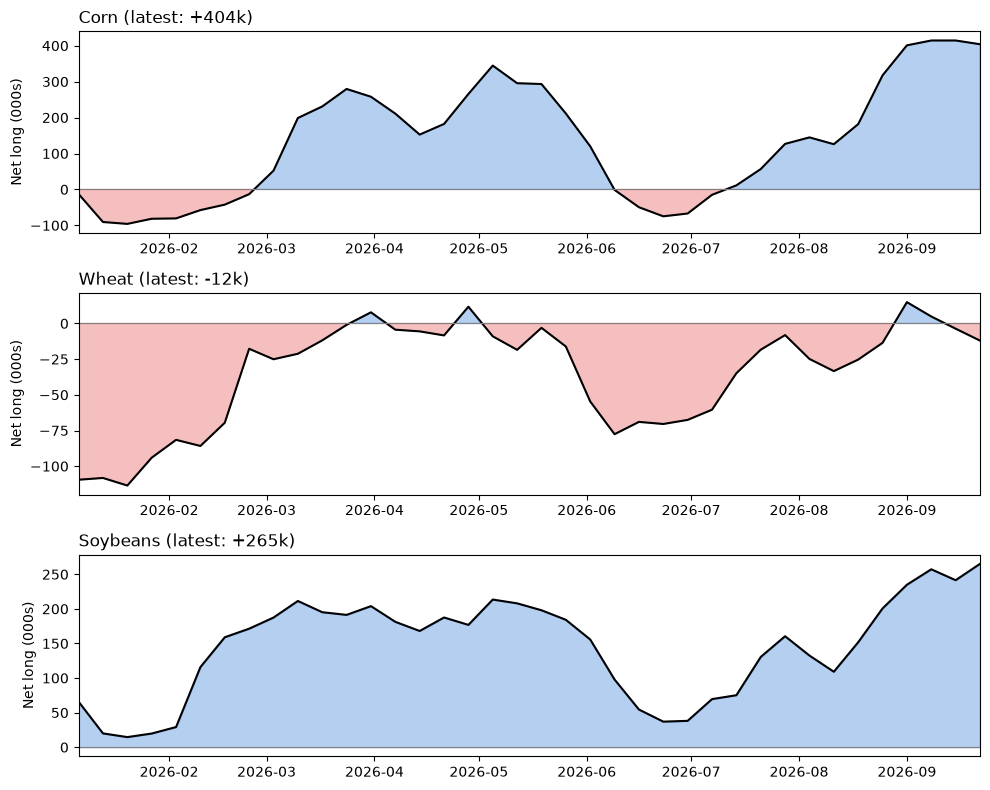

In [10]:
def plot_net(data, wasde=(), dots=False, figsize=(10, 8)):
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)
    for ax, commodity in zip(axes, data.columns):
        s = data[commodity].dropna()
        for d in [d for d in wasde if d <= s.index.max()]:
            ax.axvspan(d - pd.Timedelta(weeks=1), d + pd.Timedelta(weeks=1), color="lightgrey", alpha=0.5)
            ax.axvline(d, color="black", linewidth=1)
        ax.plot(s, color="black", marker="o" if dots else None, markersize=4)
        ax.fill_between(s.index, s, where=s > 0, color="#2a78d6", alpha=0.35, interpolate=True)
        ax.fill_between(s.index, s, where=s < 0, color="#e34948", alpha=0.35, interpolate=True)
        ax.axhline(0, color="grey", linewidth=0.8)
        ax.set_title(f"{commodity} (latest: {s.iloc[-1]:+,.0f}k)", loc="left")
        ax.set_ylabel("Net long (000s)")
        ax.set_xlim(s.index.min(), s.index.max())
        ax.tick_params(labelbottom=True)
    fig.tight_layout()
    return fig, axes


net_2026 = net.loc["2026"] / 1000
plot_net(net_2026)
plt.show()


## 3. Net long in 2026, with WASDE releases

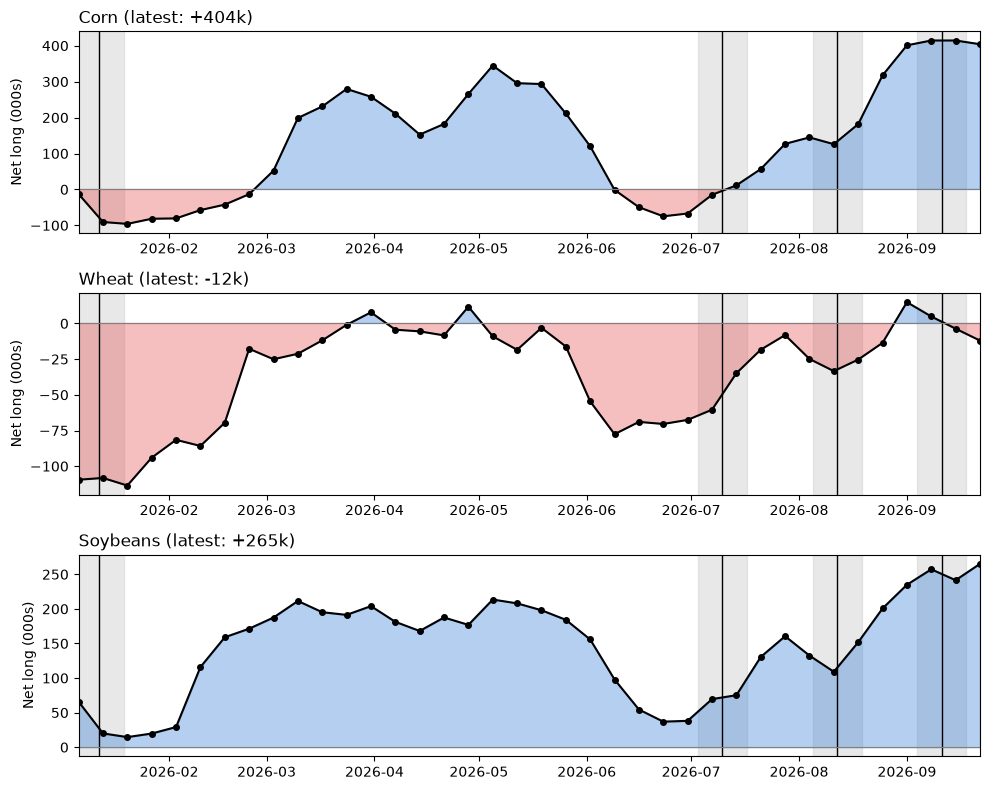

In [11]:
WASDE = pd.to_datetime(["2026-01-12", "2026-07-10", "2026-08-12", "2026-09-11"])
plot_net(net_2026, wasde=WASDE, dots=True)
plt.show()

## 4. Seasonal

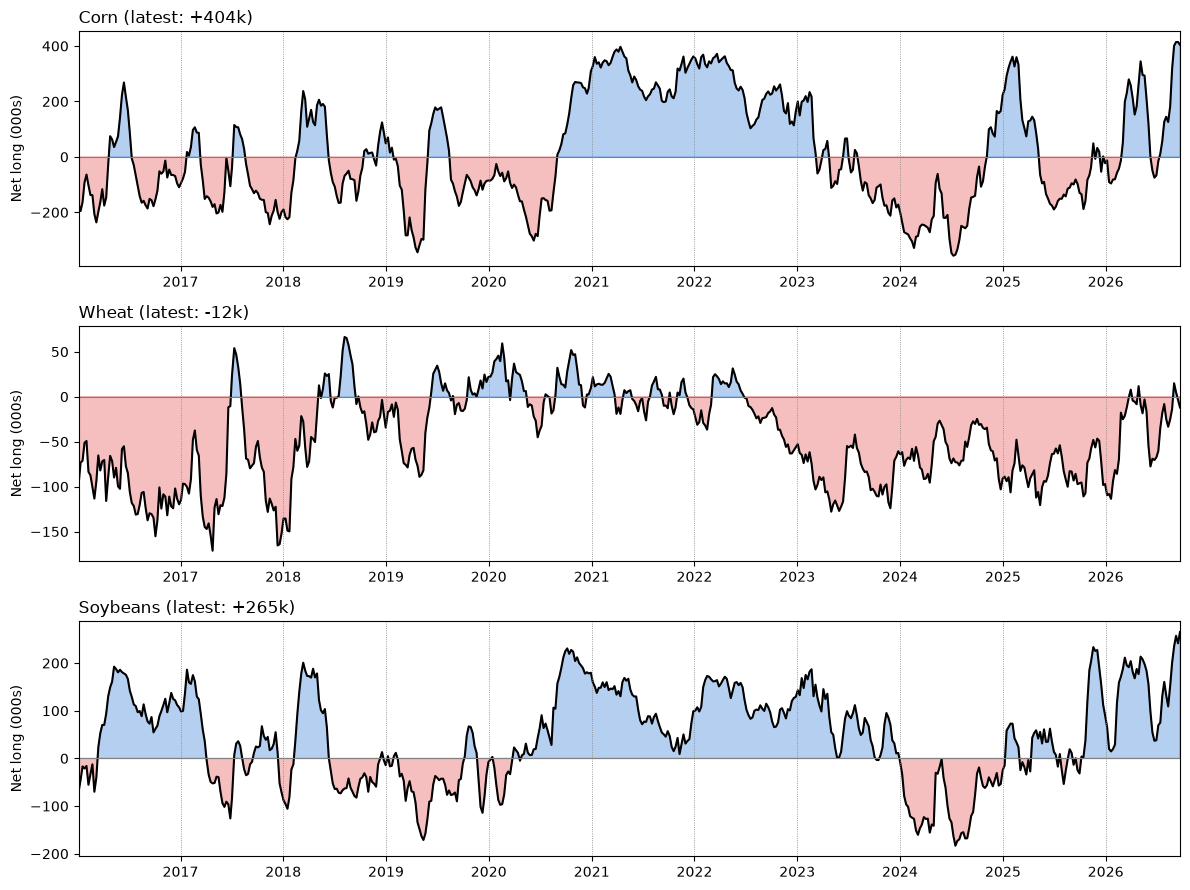

In [12]:
fig, axes = plot_net(net / 1000, figsize=(12, 9))
for ax in axes:
    for year_start in pd.date_range(net.index.min(), net.index.max(), freq="YS"):
        ax.axvline(year_start, color="grey", linewidth=0.6, linestyle=":")
plt.show()


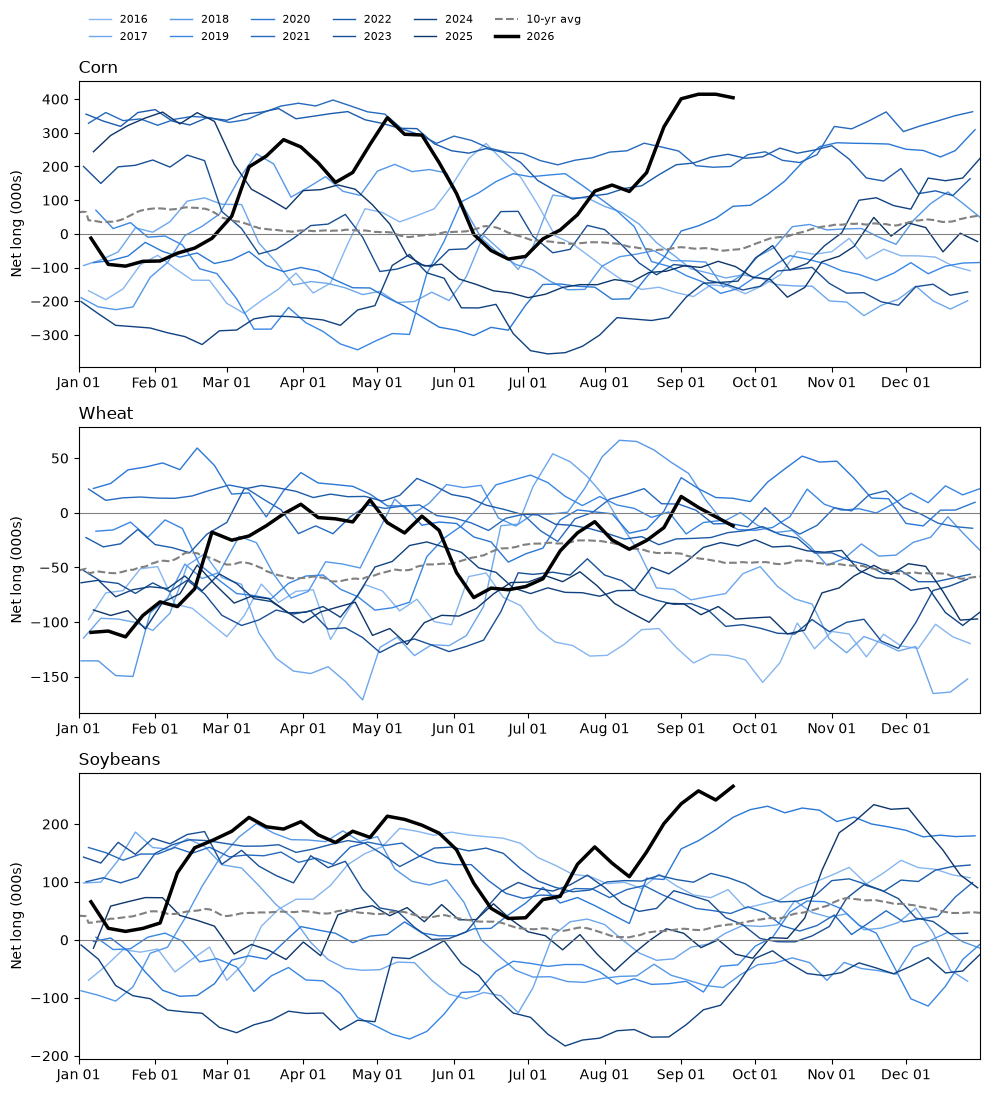

In [13]:
this_year = df["year"].max()
YEAR_COLORS = ["#86b6ef", "#6da7ec", "#5598e7", "#3987e5", "#2a78d6",
               "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"] # Oldest to newest

fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
for ax, commodity in zip(axes, MARKETS.values()):
    by_year = {year: g.set_index("season_date")["net_long"] / 1000
               for year, g in df[df["commodity"] == commodity].groupby("year")}
    past = {year: s for year, s in by_year.items() if year != this_year}

    for (year, s), color in zip(past.items(), YEAR_COLORS):
        ax.plot(s, color=color, linewidth=1, label=year)
    daily = net[commodity].resample("D").interpolate() / 1000
    daily = daily[daily.index.year != this_year]
    daily = daily[~((daily.index.month == 2) & (daily.index.day == 29))]
    ax.plot(daily.groupby(to_season(daily.index)).mean(), color="grey", linestyle="--", label="10-yr avg")
    ax.plot(by_year[this_year], color="black", linewidth=2.5, label=this_year)
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_title(commodity, loc="left")
    ax.set_ylabel("Net long (000s)")
    ax.set_xlim(pd.Timestamp("2000-01-01"), pd.Timestamp("2000-12-31"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.tick_params(labelbottom=True)

axes[0].legend(ncol=6, fontsize=8, loc="lower left", bbox_to_anchor=(0, 1.1), frameon=False)
fig.tight_layout()
plt.show()